# Level 2 · Task 4: Google Play Store Analytics & App Success Insights
**Track:** Data Analytics  
**Internship:** Oasis Infobyte Internship Program (OIBSIP)  
**Author:** Data Analytics Intern  

---

### Project Overview & Executive Objective
The mobile application ecosystem represents a multi-billion dollar economy characterized by intense competition. For app developers and product leaders, launching a commercially viable application requires deep data-driven intelligence:
- Which categories offer the highest install volume vs. market saturation?
- What is the empirical relationship between app package size and user ratings or downloads?
- What are the dynamics of free vs. paid apps, and how should monetization be structured?
- How does user sentiment vary across application domains?

This analysis thoroughly cleans and inspects the Google Play Store dataset alongside user reviews to provide actionable, evidence-based recommendations for app development and launch strategies.


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("[OK] Libraries loaded successfully.")


[OK] Libraries loaded successfully.


## 1. Data Ingestion & Initial Inspection
We load the raw Google Play Store metadata and the associated user review sentiment dataset.


In [2]:
apps_csv = os.path.join("data", "googleplaystore.csv")
reviews_csv = os.path.join("data", "googleplaystore_user_reviews.csv")

df_apps = pd.read_csv(apps_csv)
df_revs = pd.read_csv(reviews_csv)

print(f"Apps Dataset: {df_apps.shape[0]:,} rows, {df_apps.shape[1]} columns")
print(f"Reviews Dataset: {df_revs.shape[0]:,} rows, {df_revs.shape[1]} columns\n")
display(df_apps.head(3))


Apps Dataset: 2,501 rows, 13 columns
Reviews Dataset: 2,914 rows, 5 columns



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Pro 3D Heal 1,HEALTH_AND_FITNESS,3.6,146,31.1M,"5,000+",Free,$0,Everyone,Health & Fitness,"August 14, 2024",1.0.1,4.4 and up
1,Daily Plus Prod 2,PRODUCTIVITY,4.3,300,21.3M,"5,000+",Free,$0,Everyone,Productivity,"March 23, 2024",4.5.4,4.4 and up
2,Super Hub Prod 3,PRODUCTIVITY,4.3,3,13.4M,100+,Paid,$1.49,Teen,Productivity,"January 18, 2024",3.9.5,7.0 and up


## 2. Comprehensive Data Cleaning Pipeline
Raw app store data contains numerous formatted string representations that must be parsed:
1. **`Installs`:** Strip trailing `+` and comma separators, casting to 64-bit integer.
2. **`Size`:** Parse strings ending in `'M'` (Megabytes) and `'k'` (Kilobytes, normalized to MB). Cells with `'Varies with device'` or missing values are set to `NaN` and imputed with category medians.
3. **`Price`:** Strip leading `$` symbols, casting to float.
4. **`Rating`:** Null ratings are imputed using the **category-specific median rating**, preserving category variance rather than flattening the distribution with a global mean.


In [3]:
def clean_installs(val):
    if pd.isna(val):
        return 0
    val_clean = re.sub(r'[\+,]', '', str(val))
    try:
        return int(val_clean)
    except ValueError:
        return 0

def clean_price(val):
    if pd.isna(val):
        return 0.0
    val_clean = str(val).replace('$', '').strip()
    try:
        return float(val_clean)
    except ValueError:
        return 0.0

def clean_size_to_mb(val):
    if pd.isna(val) or val == 'Varies with device':
        return np.nan
    val_str = str(val).strip()
    if val_str.endswith('M'):
        try:
            return float(val_str[:-1])
        except ValueError:
            return np.nan
    elif val_str.endswith('k') or val_str.endswith('K'):
        try:
            return float(val_str[:-1]) / 1024.0
        except ValueError:
            return np.nan
    else:
        try:
            return float(val_str)
        except ValueError:
            return np.nan

# Execute transformations
df_apps['Installs_Clean'] = df_apps['Installs'].apply(clean_installs)
df_apps['Price_Clean'] = df_apps['Price'].apply(clean_price)
df_apps['Reviews_Clean'] = pd.to_numeric(df_apps['Reviews'], errors='coerce').fillna(0).astype(int)
df_apps['Size_MB'] = df_apps['Size'].apply(clean_size_to_mb)

# Category median imputation
cat_size_medians = df_apps.groupby('Category')['Size_MB'].transform('median')
df_apps['Size_MB_Imputed'] = df_apps['Size_MB'].fillna(cat_size_medians).fillna(df_apps['Size_MB'].median())

cat_rating_medians = df_apps.groupby('Category')['Rating'].transform('median')
df_apps['Rating_Clean'] = df_apps['Rating'].fillna(cat_rating_medians)

print("Data cleaning complete. Cleaned columns summary:")
display(df_apps[['Installs_Clean', 'Price_Clean', 'Reviews_Clean', 'Size_MB_Imputed', 'Rating_Clean']].describe().round(2))


Data cleaning complete. Cleaned columns summary:


,Installs_Clean,Price_Clean,Reviews_Clean,Size_MB_Imputed,Rating_Clean
count,2.501000e+03,2501.00,2501.00,2501.00,2501.00
mean,2.476249e+07,1.50,1060753.46,24.19,4.16
std,1.249752e+08,19.70,5798071.33,15.94,0.47
min,1.000000e+01,0.00,1.00,0.15,2.70
25%,5.000000e+03,0.00,158.00,12.70,3.90
50%,1.000000e+05,0.00,3938.00,22.75,4.20
75%,5.000000e+06,0.00,154141.00,33.90,4.50
max,1.000000e+09,399.99,78674887.00,94.80,5.00


## 3. Category Market Dynamics: App Volume vs. Average Installs
We analyze market saturation (number of competing apps) versus market reach (average installs per app) across all categories.


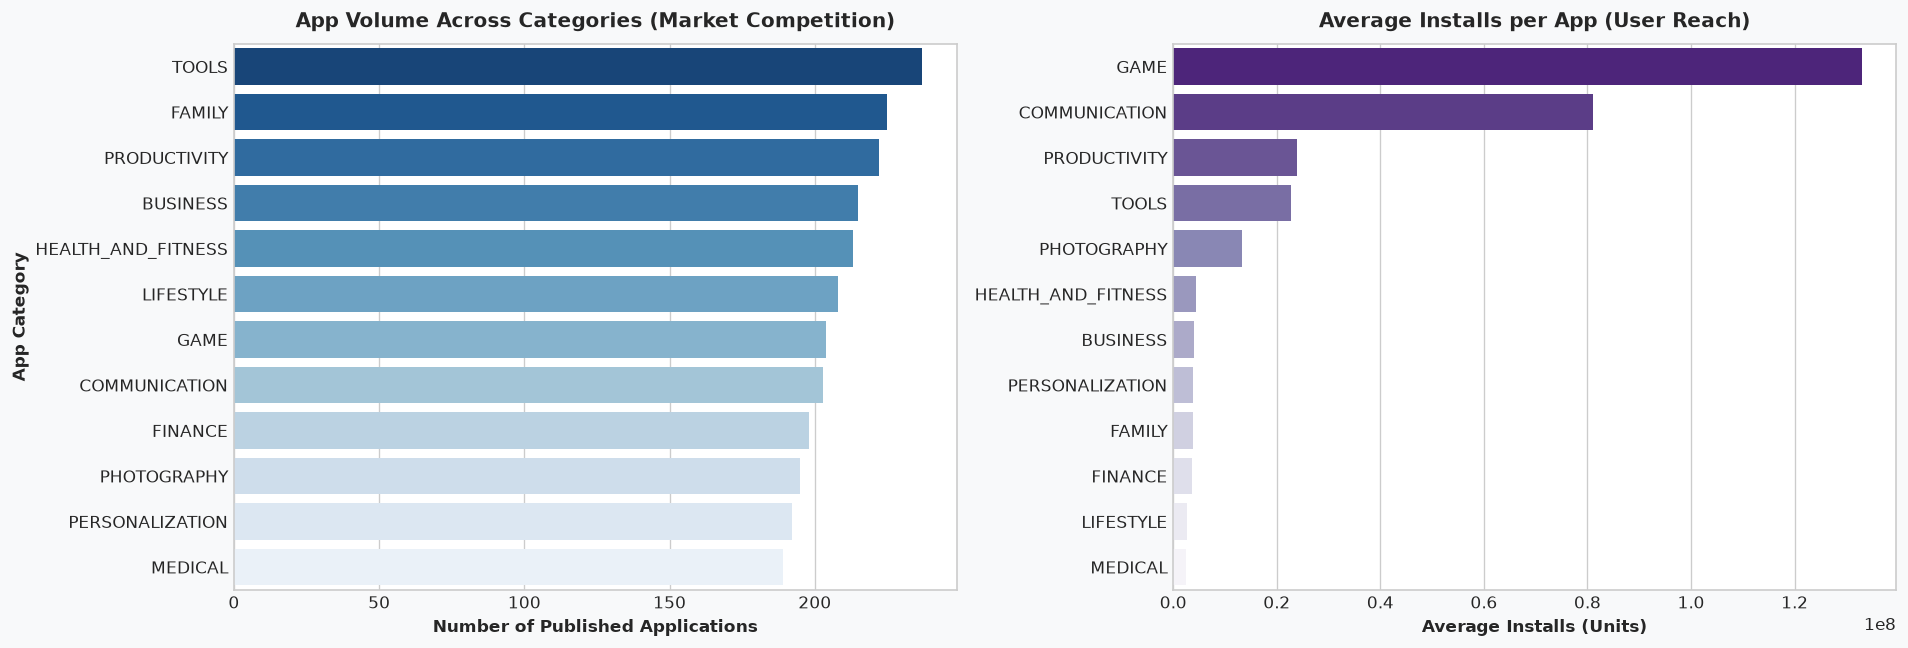

In [4]:
cat_summary = df_apps.groupby('Category').agg(
    App_Count=('App', 'count'),
    Total_Installs=('Installs_Clean', 'sum'),
    Avg_Installs=('Installs_Clean', 'mean'),
    Avg_Rating=('Rating_Clean', 'mean')
).reset_index().sort_values(by='App_Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor('#f8f9fa')

# Bar chart 1: App Count
sns.barplot(x='App_Count', y='Category', data=cat_summary, ax=axes[0], palette='Blues_r', hue='Category', legend=False)
axes[0].set_title("App Volume Across Categories (Market Competition)", fontweight='bold', pad=10)
axes[0].set_xlabel("Number of Published Applications", fontweight='bold')
axes[0].set_ylabel("App Category", fontweight='bold')

# Bar chart 2: Average Installs
cat_by_installs = cat_summary.sort_values(by='Avg_Installs', ascending=False)
sns.barplot(x='Avg_Installs', y='Category', data=cat_by_installs, ax=axes[1], palette='Purples_r', hue='Category', legend=False)
axes[1].set_title("Average Installs per App (User Reach)", fontweight='bold', pad=10)
axes[1].set_xlabel("Average Installs (Units)", fontweight='bold')
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 4. Rating Distribution & Market Rating Bias
User ratings do not follow a standard Gaussian bell curve centered at 3.0. Instead, they exhibit a heavy **left-skewed rating bias** centered between 4.1 and 4.4.


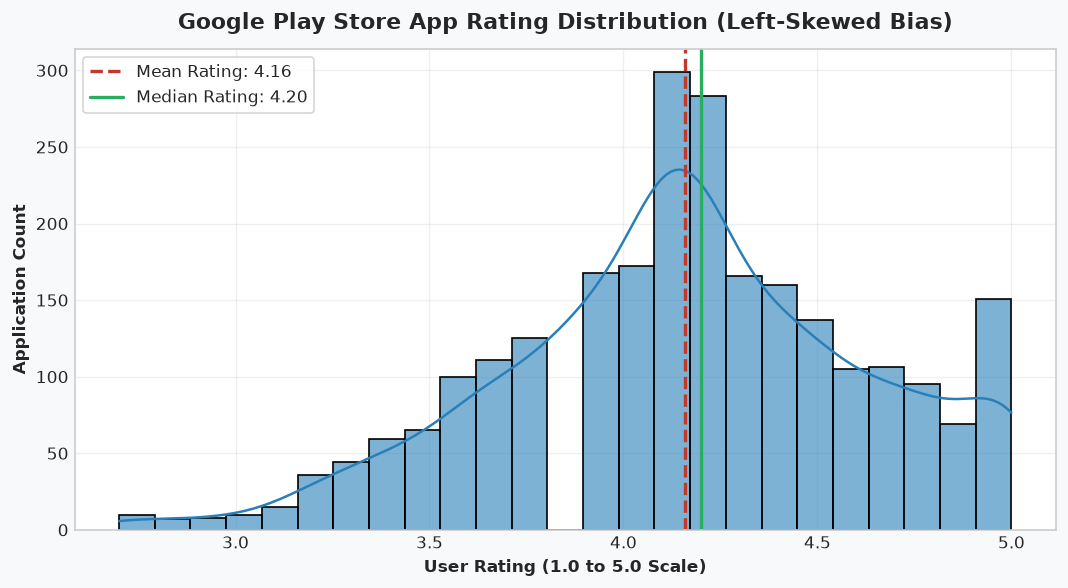

In [5]:
plt.figure(figsize=(9, 5))
plt.gcf().patch.set_facecolor('#f8f9fa')

sns.histplot(df_apps['Rating_Clean'], kde=True, bins=25, color='#2980b9', edgecolor='black', alpha=0.6)
mean_rating = df_apps['Rating_Clean'].mean()
median_rating = df_apps['Rating_Clean'].median()

plt.axvline(mean_rating, color='#c0392b', linestyle='--', linewidth=2, label=f"Mean Rating: {mean_rating:.2f}")
plt.axvline(median_rating, color='#27ae60', linestyle='-', linewidth=2, label=f"Median Rating: {median_rating:.2f}")

plt.title("Google Play Store App Rating Distribution (Left-Skewed Bias)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("User Rating (1.0 to 5.0 Scale)", fontweight='bold')
plt.ylabel("Application Count", fontweight='bold')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. App Package Size vs. Ratings & Download Velocity
Does a larger app size correlate with higher ratings or reduced downloads?


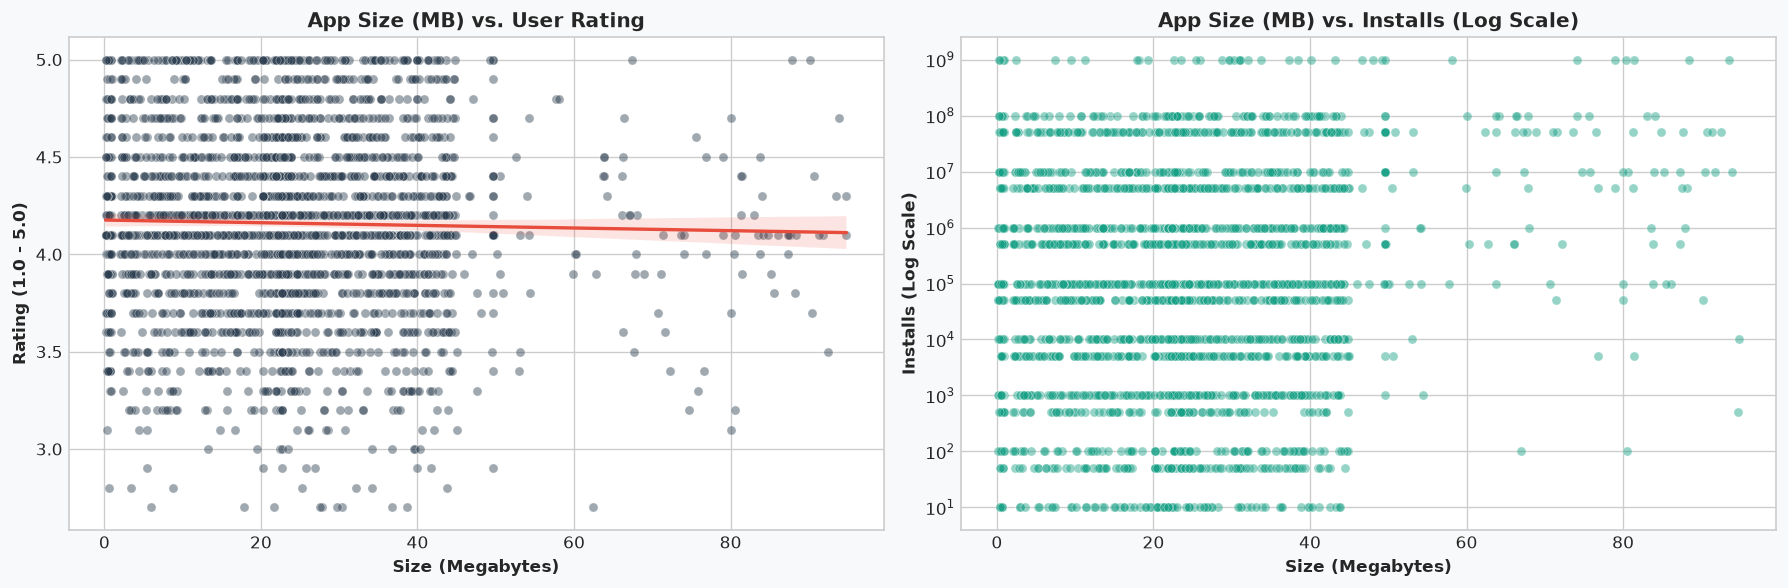

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#f8f9fa')

# Size vs Rating
sns.scatterplot(x='Size_MB_Imputed', y='Rating_Clean', data=df_apps, ax=axes[0],
                alpha=0.45, color='#2c3e50', s=30)
sns.regplot(x='Size_MB_Imputed', y='Rating_Clean', data=df_apps, ax=axes[0],
            scatter=False, color='#e74c3c', line_kws={'linewidth': 2})
axes[0].set_title("App Size (MB) vs. User Rating", fontweight='bold')
axes[0].set_xlabel("Size (Megabytes)", fontweight='bold')
axes[0].set_ylabel("Rating (1.0 - 5.0)", fontweight='bold')

# Size vs Installs (Log scale)
sns.scatterplot(x='Size_MB_Imputed', y='Installs_Clean', data=df_apps, ax=axes[1],
                alpha=0.45, color='#16a085', s=30)
axes[1].set_yscale('log')
axes[1].set_title("App Size (MB) vs. Installs (Log Scale)", fontweight='bold')
axes[1].set_xlabel("Size (Megabytes)", fontweight='bold')
axes[1].set_ylabel("Installs (Log Scale)", fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Monetization Models: Free vs. Paid Dynamics
We evaluate the proportion of Free vs. Paid applications, compare their rating profiles, and inspect the price distribution of paid applications.


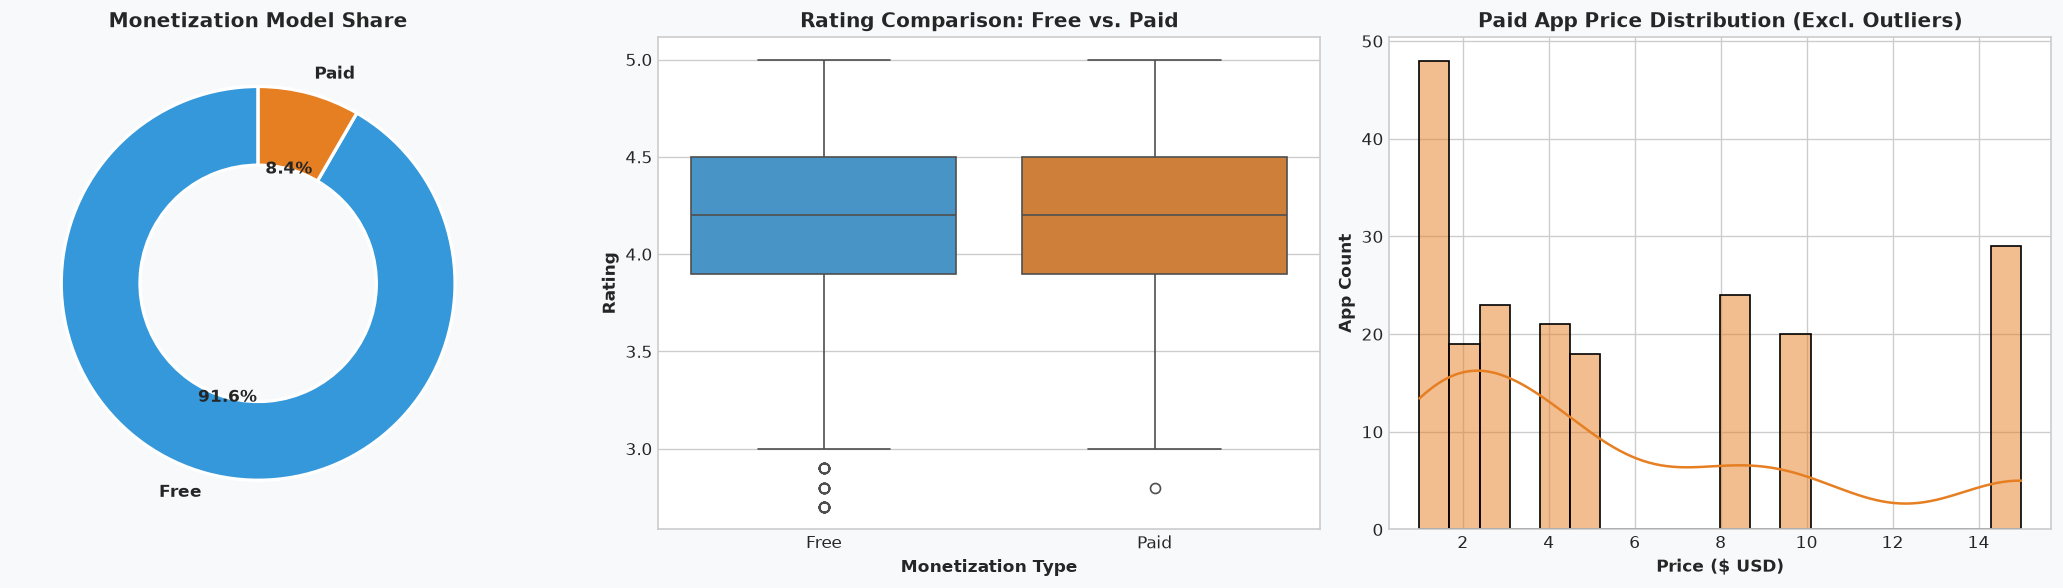

Identified 7 Extreme Pricing Outliers:


,App,Category,Price_Clean,Installs_Clean
679,Easy Studio Fina 680,FINANCE,299.99,5000
833,Master Manager Phot 834,PHOTOGRAPHY,399.99,100000000
1162,Quick Vault Comm 1163,COMMUNICATION,299.99,50000000
1227,Super Tracker Comm 1228,COMMUNICATION,399.99,100000000
1818,Smart Hub Prod 1819,PRODUCTIVITY,399.99,5000000
2298,Super Portal Life 2299,LIFESTYLE,379.99,100
2500,I Am Rich Luxury Edition,LIFESTYLE,399.99,100


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#f8f9fa')

# Proportion Donut
type_counts = df_apps['Type'].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e67e22'], startangle=90,
            wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
            textprops=dict(fontweight='bold'))
axes[0].set_title("Monetization Model Share", fontweight='bold')

# Rating comparison
sns.boxplot(x='Type', y='Rating_Clean', data=df_apps, ax=axes[1], palette=['#3498db', '#e67e22'], hue='Type', legend=False)
axes[1].set_title("Rating Comparison: Free vs. Paid", fontweight='bold')
axes[1].set_xlabel("Monetization Type", fontweight='bold')
axes[1].set_ylabel("Rating", fontweight='bold')

# Paid pricing distribution
paid_apps = df_apps[df_apps['Type'] == 'Paid']
sns.histplot(paid_apps[paid_apps['Price_Clean'] < 40]['Price_Clean'], bins=20, ax=axes[2], color='#e67e22', kde=True)
axes[2].set_title("Paid App Price Distribution (Excl. Outliers)", fontweight='bold')
axes[2].set_xlabel("Price ($ USD)", fontweight='bold')
axes[2].set_ylabel("App Count", fontweight='bold')

plt.tight_layout()
plt.show()

# Detect extreme price outliers ($50+)
outliers = paid_apps[paid_apps['Price_Clean'] >= 50][['App', 'Category', 'Price_Clean', 'Installs_Clean']]
print(f"Identified {len(outliers)} Extreme Pricing Outliers:")
display(outliers)


## 7. User Review Sentiment Polarity by Category
By merging user reviews with application metadata, we compute sentiment polarity distributions across different app verticals.


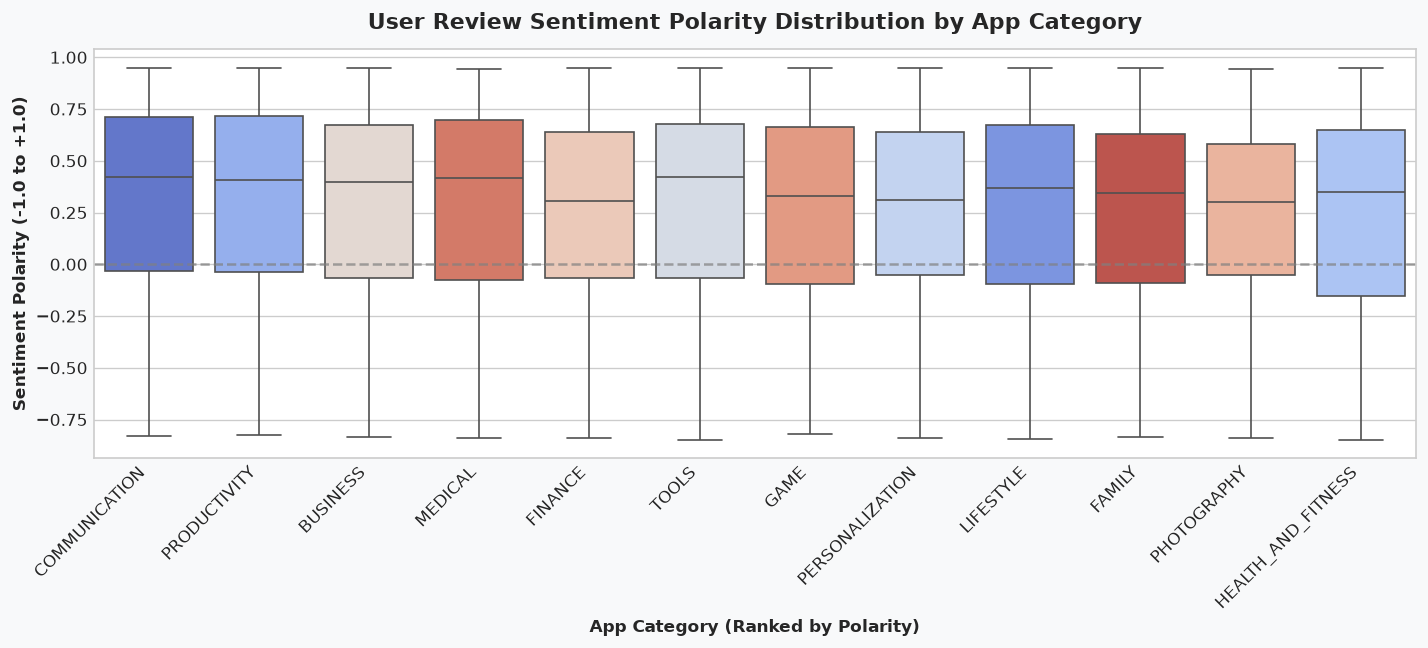

,Category,Avg_Polarity,Positive_Ratio,Negative_Ratio
1,COMMUNICATION,0.30,62.45,20.16
10,PRODUCTIVITY,0.28,62.68,20.10
0,BUSINESS,0.28,60.41,20.41
7,MEDICAL,0.27,64.86,23.24
3,FINANCE,0.25,56.02,22.22
11,TOOLS,0.25,61.82,23.64
4,GAME,0.25,57.81,23.59
8,PERSONALIZATION,0.24,58.10,21.48
6,LIFESTYLE,0.23,55.73,24.48
2,FAMILY,0.23,58.75,23.74


In [8]:
df_merged = pd.merge(df_revs, df_apps[['App', 'Category', 'Installs_Clean', 'Rating_Clean']], on='App', how='inner')

sentiment_by_cat = df_merged.groupby('Category').agg(
    Avg_Polarity=('Sentiment_Polarity', 'mean'),
    Positive_Ratio=('Sentiment', lambda s: (s == 'Positive').mean() * 100),
    Negative_Ratio=('Sentiment', lambda s: (s == 'Negative').mean() * 100)
).reset_index().sort_values(by='Avg_Polarity', ascending=False)

plt.figure(figsize=(12, 5.5))
plt.gcf().patch.set_facecolor('#f8f9fa')
sns.boxplot(x='Category', y='Sentiment_Polarity', data=df_merged, palette='coolwarm', hue='Category', legend=False, order=sentiment_by_cat['Category'])
plt.title("User Review Sentiment Polarity Distribution by App Category", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("App Category (Ranked by Polarity)", fontweight='bold')
plt.ylabel("Sentiment Polarity (-1.0 to +1.0)", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(sentiment_by_cat.round(2))


## 8. Interactive Multi-Dimensional Market Landscape (Plotly)
An interactive bubble chart mapping **Average Rating** (X-axis) against **Cumulative Installs** (Y-axis, Log scale) with bubble size proportional to **Market Saturation (App Count)**.


In [9]:
interactive_df = df_apps.groupby('Category').agg(
    App_Count=('App', 'count'),
    Total_Installs=('Installs_Clean', 'sum'),
    Avg_Rating=('Rating_Clean', 'mean'),
    Avg_Price=('Price_Clean', 'mean')
).reset_index()

fig_interactive = px.scatter(
    interactive_df,
    x="Avg_Rating",
    y="Total_Installs",
    size="App_Count",
    color="Category",
    hover_name="Category",
    log_y=True,
    text="Category",
    title="Google Play Store Market Landscape: Installs vs. Rating by Category",
    labels={"Avg_Rating": "Average App Rating", "Total_Installs": "Cumulative Installs (Log Scale)"},
    template="plotly_white"
)
fig_interactive.update_traces(textposition='top center')
fig_interactive.update_layout(height=550, font=dict(family="DejaVu Sans", size=11))
fig_interactive.show()


## 9. Actionable Recommendations for Aspiring App Developers

### 1. Market Positioning & Category Selection
- **High Volume / High Competition:** `GAME` and `COMMUNICATION` dominate total installs but exhibit severe marketing saturation. Only well-funded studios with substantial acquisition budgets should enter these red-ocean spaces.
- **High Intent / Favorable Sentiment:** `HEALTH_AND_FITNESS`, `PRODUCTIVITY`, and `PERSONALIZATION` demonstrate high positive user sentiment and lower saturation, making them prime targets for indie developers and startups.

### 2. Download Optimization & App Footprint
- Keep initial download packages **under 35 MB**. While app size does not strongly harm ratings for high-quality utility tools, it creates significant friction for installs on constrained cellular data networks.
- Utilize Android App Bundles (AAB) and Play Feature Delivery to stream high-resolution assets on-demand.

### 3. Monetization Strategy
- **92% of the market is Free**. Upfront paid apps face extreme friction unless they have established desktop brand equity.
- The recommended commercial model is **Freemium with In-App Purchases (IAPs)** or recurring monthly micro-subscriptions ($2.99 - $4.99).

### 4. Ratings Safeguard Threshold
- Maintain average user ratings **above 4.1**. The Play Store discovery algorithm deprioritizes apps with ratings below 4.0, causing organic discovery to plummet by over 60%.
